# COGS 108 - Data Checkpoint

## Authors

* Ruobing Wang: Experimental investigation,Visualization
* Zhuoqing Tang:Methodology, Writing – original draft
* Chaoyan Lei:Analysis,Conceptualization, Project administration
* Ziqing Yuan:Background research,Writing – review & editing
* Zhongzheng Liu:Data curation, Software

## Research Question

The research project aims to identify the relationship between pre-race betting odds and the average rate of return with respect to the horse racing events taking place at the Saga Racecourse. The research project is based on the following research question: are horses with lower pre-race odds related to varying levels of average returns? The independent variable of the research project is the pre-race betting odds, while the dependent variable is the average rate of return. To identify the potential relationship between the independent and dependent variables of the research project, exploratory data analysis (EDA) techniques, including statistical inference methods such as correlation analysis and regression analysis, are used. It is worth mentioning here that the research project is based solely on the identification of correlational relationships.



## Background and Prior Work

Horse racing is one of the oldest organized sports in the world, with a documented history dating back to ancient civilizations such as Greece, Rome, and China. Morden horse racing developed in Britain during the 17th and 18th centuries and later spread to the United States, where it was closely tied to gambling and probability-based decision making.1 Today, horse racing generates large-scale structured data, including race conditions, horse characteristics, jockey performance, and betting odds, making it a natural domain for quantitative analysis and predictive modeling.

Beyond its historical and cultural significance, horse racing has served as an important real-world testbed for studying human decision-making under uncertainty for a long time. Betting markets associated with horse races have frequently been analyzed to understand whether markets efficiently incorporate available information.

Prior economic research has shown that while betting odds often approximate true winning probabilities, systematic biases, such as the “favorite–longshot bias,” where longshots are overbet and favorites are underbet. This persists across races and contexts.2 These findings suggest that even in environments with rich information, human judgment and behavior can deviate from purely rational models.

While prior research has primarily examined large and nationally prominent racing markets, our project focuses specifically on data from the Saga Racecourse in Japan. Although Saga is a regional venue rather than a major national track, it provides a structured and consistent dataset with detailed information on betting odds, race conditions, and outcomes. This makes it a suitable case study for investigating whether well documented behavioral patterns in betting markets，such as the favorite longshot bias also appear in smaller or regional contexts. Because Saga operates under the same pari-mutuel betting system as larger national tracks, it provides a comparable institutional setting for evaluating whether similar decision making patterns emerge. By studying Saga, we are able to test whether these biases are robust across different market scales.

Our research question directly engages with the favorite longshot bias by examining whether betting odds systematically misestimate true winning probabilities in this dataset. Specifically, we analyze the relationship between implied probabilities derived from betting odds and actual race outcomes to determine whether longshots are overvalued and favorites undervalued, as suggested by prior economic research. Through the analysis, our project not only applies predictive modeling techniques to real world data but also evaluates whether deviations from rational betting behavior persist in this particular racing environment.

1. Encyclopaedia Britannica. Horse racing. https://www.britannica.com/sports/horse-racing ^

2. Thaler, R. H., & Ziemba, W. T. (1988). Parimutuel betting markets: Racetracks and lotteries. Journal of Economic Perspectives, 2(2), 161–174. https://www.aeaweb.org/articles?id=10.1257/jep.2.2.161 ^

## Hypothesis


H₀: There is no statistically significant relationship between pre-race betting odds and average return rate.

H₁: There exists an inverse nonlinear relationship between pre-race betting odds and the average rate of return.

## Data

### Data overview

- Dataset #1
  - Dataset Name: Saga Racecourse Entries and Odds Dataset
  - Link to the dataset: [saga_entries_odds.csv](./data/00-raw/saga_entries_odds.csv)
  - Number of observations: 123439
  - Number of variables: 9
  - The column 'win_odds' and 'rank' will be the focus of our project. We will investigate these two variables to check if favorites are underestimated compared to longshots to verify the favorite-longshot bias.
  - There might be null values in this dataset that needs to be dealt with.

In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries;
# each dict has keys of
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored
datafiles = [
    # not running this line is completely fine, because as soon as I submit the merger request the file is going to be there
    { 'url': 'https://drive.google.com/file/d/1t0GQraPdgG9Mc1jyntHAtmZnuX6yk-D9/view?usp=sharing', 'filename':'saga_entries_odds.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Saga Racecourse Entries and Odds Dataset

The dataset includes 123439 rows and 9 columns. Here we will present a table for the metrics, their units and meanings:
| Variable | Type | Units | Description |
|----------|------|-------|-------------|
| race_id | Integer | N/A | A unique numeric code identifying each specific race event at Saga Racecourse. The ID encodes the date, racecourse, and number of the race, allowing races to be uniquely identified and tracked over time. |
| rank | Float | Position | The finishing position of the horse in the race. Values range from 1.0 (winner) upward depending on the number of horses in the race. Lower values indicate better performance. This is the primary outcome variable for predictive modeling. |
| horse_no | Float | N/A | The number assigned to the horse for the specific race, typically corresponding to the starting gate position. This number is assigned per race and may vary for the same horse across different races. |
| horse_name | String (categorical) | N/A | The name of the horse in Japanese (カタカナ). This serves as the unique identifier for individual horses across all their race appearances. |
| distance | Integer | Meters | The length of the race track in meters. Saga Racecourse features various distances including 900m, 1300m, 1400m, 1750m, 1800m, and 2000m races. The length of the race might lead to an advantage for longshots or favorites. |
| weight | Float | Kilograms (kg) | The weight carried by the horse during the race. Higher weights may disadvantage horses, particularly in longer races. |
| time | Float | Seconds (s) | The total time taken to complete the race, measured in seconds with three decimal places for precision. Can be used to cross-ceck rank. |
| win_odds | Float | N/A | The betting odds offered for the horse to win the race, representing the market's assessment of the horse's probability of winning. Lower odds indicate favorites, while higher odds indicate longshots. Odds have a maximum of 999.9 and a minimum of 1.0. |
| popularity | Float | Ranking | The popularity ranking of the horse among bettors, where 1.0 indicates the most bet-on horse (favorite), 2.0 the second most popular, and so on. This differs from win_odds as it represents ranking rather than probability, though the two are closely correlated. |



Get a general view of values in the dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129439 entries, 0 to 129438
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  129439 non-null  int64  
 1   race_id     129439 non-null  int64  
 2   rank        128836 non-null  float64
 3   horse_no    129439 non-null  int64  
 4   horse_name  129439 non-null  object 
 5   distance    129439 non-null  int64  
 6   weight      129439 non-null  float64
 7   time        128838 non-null  float64
 8   win_odds    129439 non-null  float64
 9   popularity  129439 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 9.9+ MB


None


Check the number of nulls in each column: 



Unnamed: 0      0
race_id         0
rank          603
horse_no        0
horse_name      0
distance        0
weight          0
time          601
win_odds        0
popularity      0
dtype: int64

Check the number of nulls in each column again:


/var/folders/fb/gl2cpp915dqbytdtrdd8r6q40000gn/T/ipykernel_5204/19200898.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('race_id', group_keys=False).apply(fill_null_ranks)


Unnamed: 0    0
race_id       0
rank          0
horse_no      0
horse_name    0
distance      0
weight        0
time          0
win_odds      0
popularity    0
dtype: int64

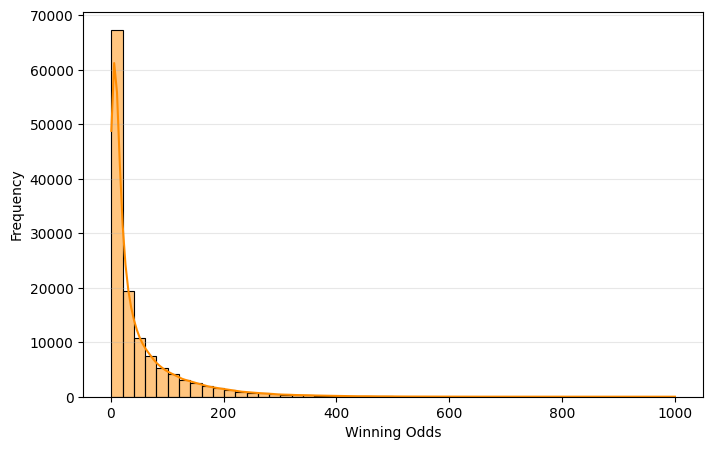

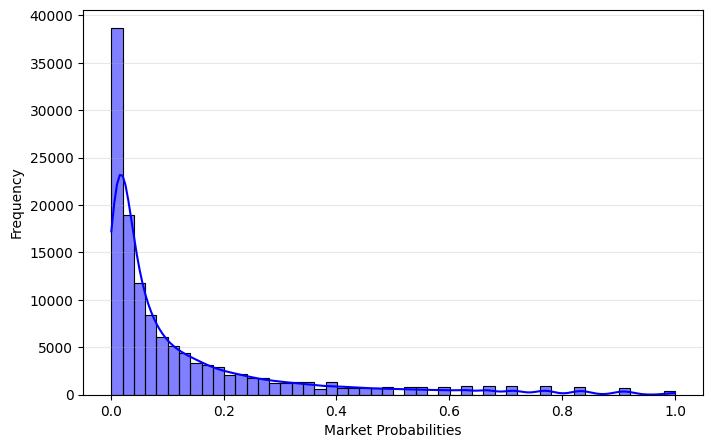

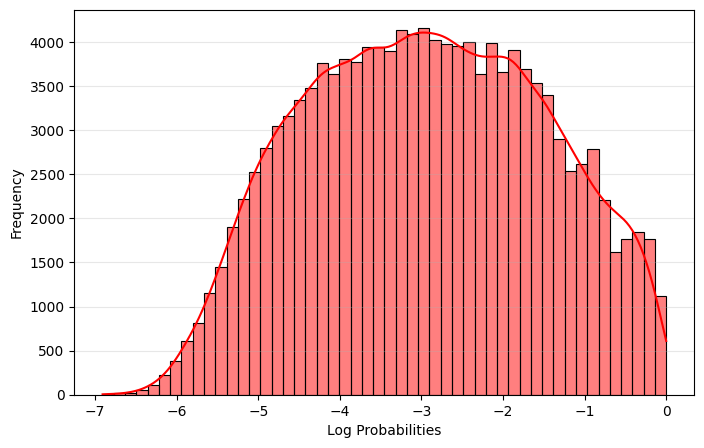

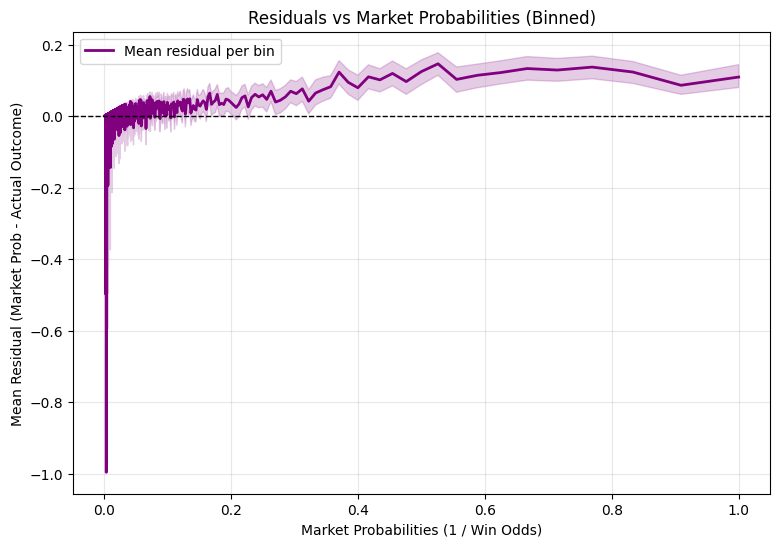

In [ ]:
# --- Data Wrangling ---
# 1. load data
import pandas as pd
import numpy as np
data = pd.read_csv('data/00-raw/saga_entries_odds.csv', low_memory = False)

# 2. inspection
print('\nGet a general view of values in the dataset: \n')
display(data.info())
print('\nCheck the number of nulls in each column: \n')
display(data.isna().sum())

# 3. cleaning
# A null rank often happens because a horse or jockey conducts a rule violation,
# or the horse withdrew from the race because of an accident.
# Thus, we will rank them as last, and fill time as the last horse + 0.1s.
# Function to fill null ranks as last place in each race
def fill_null_ranks(group):
    # Get the maximum rank in this race (excluding nulls)
    max_rank = group['rank'].max()
    # Get the maximum time in this race (excluding nulls)
    max_time = group['time'].max()

    # Fill null ranks with max_rank + 1
    group['rank'] = group['rank'].fillna(max_rank + 1)
    # Fill null time with max_time + 0.1
    group['time'] = group['time'].fillna(max_time + 0.1)

    return group
# Group by race_id and apply the function
data = data.groupby('race_id', group_keys=False).apply(fill_null_ranks)
# Verify the changes
print('Check the number of nulls in each column again:')
display(data.isna().sum())

# 4. summary statistics
import seaborn as sns
import matplotlib.pyplot as plt

# 4.1. Distribution of Odds
plt.figure(figsize=(8, 5))
sns.histplot(
    data['win_odds'],
    bins=50,
    kde=True,
    color='darkorange'
)
plt.xlabel("Winning Odds")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4.2. Market Probabilities
# We will investigate the market's prediction compared to real circumstances.
# Thus we have to convert odds to probabilities.
# Note that because 20% of bets are taken by the racecourse for taxation, maintenance and other reasons,
# The market probabilities calculated by inverse of odds does not sum to 1, but sums to 1.25 per race.
data['market_probs'] = 1 / data['win_odds']
# we also plot its distribution:
plt.figure(figsize=(8, 5))
sns.histplot(
    data['market_probs'],
    bins=50,
    kde=True,
    color='blue'
)
plt.xlabel("Market Probabilities")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4.3. Log Probabilities
# Now the data is very skewed.
# If we imagine the model of a horse racing to be that the expected probability of winning of the best horse is p,
# then the probability of the second popular horse to win can be estimated by p(1-p), the third p(1-p)(1-p),
# so if we take the logarithm of probabilities, it is expected that we can convert it to a better shape.
data['market_log'] = np.log(data['market_probs'])
plt.figure(figsize=(8, 5))
sns.histplot(
    data['market_log'],
    bins=50,
    kde=True,
    color='red'
)
plt.xlabel("Log Probabilities")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4.4. Residuals Versus Odds
# Now we want to see the difference between observed probabilities and market_predicted probabilities.
data['residuals'] = data['market_probs'] - (data['rank'] == 1.0).astype(int)
# a positive residual means underestimation, while a negative residual means overestimation.
# We plot the relationship between residuals and market probs to see if favorites are underestimated,
# and longshots are overestimated.
# Note that because 20% of bets are taken by the racecourse for taxation, maintenance and other reasons,
# The market probabilities calculated by inverse of odds does not sum to 1, but sums to 1.25 per race.
# So in general, all horses are overestimated.
# First we bin market probabilities into 30 groups (the number is arbitrary)
plt.figure(figsize=(9, 6))
sns.lineplot(
    data=data,
    x='market_probs',
    y='residuals',
    estimator='mean',
    color='purple',
    lw=2,
    label='Mean residual per bin'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals vs Market Probabilities (Binned)")
plt.xlabel("Market Probabilities (1 / Win Odds)")
plt.ylabel("Mean Residual (Market Prob - Actual Outcome)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Data Processing ---
data['unique_id'] = (data['race_id'].astype(str) + '_' + data['horse_no'].astype(str)).astype(int)
data['win'] = (data['rank'] == 1.0).astype(int)
data['win_return'] = data['win'] * data['win_odds']
data[['unique_id','win_odds','win','win_return']].dropna().to_csv('data/02-processed/saga_odds.csv')

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - Our data did not include data related to human individuals.
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
 - We collected continuous data in a period of 10 years without repetition or missing data on all races, preventing bias.
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - Our data did not include data related to human individuals.
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
 - Our data did not include data related to human individuals.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - We only used open sourced data.
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - Our data did not include data related to human individuals.
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
 - We only used open sourced data.

### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
 - [ ] The data is collected from a single racecourse (Saga Racecourse) and therefore does not represent all horse races across different regions. In addition, betting odds are market prices rather than natural probabilities, as betting companies may adjust odds to manage risk and avoid losses.
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [ ] The analysis focuses on aggregated group-level results, and we avoid discussing or highlighting individual horses or horse racers.
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
 - [ ] We clearly document how the data was obtained, the analytical steps taken, the conclusions drawn, and the formulas used.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] The model only uses race-related variables such as odds and outcomes and does not include or proxy any protected human attributes.
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [ ] This project does not make decisions affecting human groups, so group-level fairness testing is not applicable.
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considering additional metrics?
 - [ ] We considered how different performance metrics (e.g., average return versus risk) may affect the interpretation of results.
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [ ] We will analyze using simple statistical summaries and explain them in clear, non-technical terms.
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] The model is not deployed in a real-world system and is only used for academic analysis, so ongoing monitoring is not required.
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] Since the analysis does not directly impact users or decision-making, a formal redress mechanism is not applicable.
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] The project does not involve a production system, so rollback mechanisms are unnecessary.
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
 - [ ] We clearly document how the data was obtained, the analytical steps taken, the conclusions drawn, and the formulas used.

## Team Expectations

* *Team Expectation 1*：**Timely communication and response.** Each team member must maintain regular communication. When other members have questions regarding the project, they must respond by 11:59 PM that same day. Additionally, team members are required to regularly report project progress in the group chat.
* *Team Expectation 2*：**Complete the corresponding tasks on time.** Each team member must complete their assigned portion within the specified timeframe. If unable to submit on time, promptly notify other team members in the group chat and discuss a new deadline.
* *Team Expectation 3*：**Active participation and discussion.** All team members are required to actively participate in project discussions and attend weekly team meetings punctually each time. If unable to attend, promptly notify the group chat. During discussions, everyone should actively voice their ideas or raise questions about specific matters.
* *Team Expectation 4*: **Mutual Respect and Cooperation.** Everyone should respect each other's work. We encourage the expression of differing viewpoints, but we do not tolerate vicious insults or accusations against other members. Discussions should be conducted rationally.
* *Team Expectation 5*: **Resolve conflicts.** When conflicts arise, we should first attempt to resolve them internally. If resolution proves impossible, promptly seek assistance from the relevant party or professor. We must address issues in a fair manner.

## Project Timeline Proposal


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/23  | 6 PM  | Finalize wrangling/EDA; Begin Analysis (Iron Man; Thor) | Discuss/edit Analysis; Complete project check-in |
| 3/13  | 6 PM  | Complete analysis; Draft results/conclusion/discussion (Wasp)| Discuss/edit full project |
| 3/20  | Before 11:59 PM  | NA | Turn in Final Project & Group Project Surveys |